In [1]:
from astropy import units as u
from astropy.coordinates import SkyCoord
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#c=skycoords()
dpi=300
size=12
labelsize=6
axislabelsize=5
ticksize=6
titlesize=16
msize=50
linewidth=0.7
marker='*'
cmap='Reds'
df=pd.read_csv("datasummary.csv")
df2=pd.read_csv("nearstar.csv")
#df

In [2]:
l=df["l"].to_numpy()
b=df["b"].to_numpy()
distance=df["distance(pc)"].to_numpy()
id=df["Identifier"].to_numpy()
CRILAlpha=df["CRI L Alpha"].to_numpy()
CRIR=df["CRI R"].to_numpy()
CRIK=df["CRI K"].to_numpy()
c=SkyCoord(l=l*u.degree,b=b*u.degree,frame='galactic')

#ra_rad=c.ra.wrap_at(180*u.deg).radian
#dec_rad=c.dec.radian



ls=359.94423568
bs=-00.04616002
distances=8.2e3

cs=SkyCoord(l=ls*u.degree,b=bs*u.degree,frame='galactic')
cp=SkyCoord(l=90*u.degree,b=90*u.degree,frame='galactic')

l2=df2["l"].to_numpy()
b2=df2["b"].to_numpy()
distance2=df2["distance(pc)"].to_numpy()
id2=df2["Identifier"].to_numpy()
c2=SkyCoord(l=l2*u.degree,b=b2*u.degree,frame='galactic')




C:\Users\Wasabi\AppData\Local\Temp\ipykernel_31696\3086984642.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = cm.get_cmap(cmap) if isinstance(cmap, str) else cmap


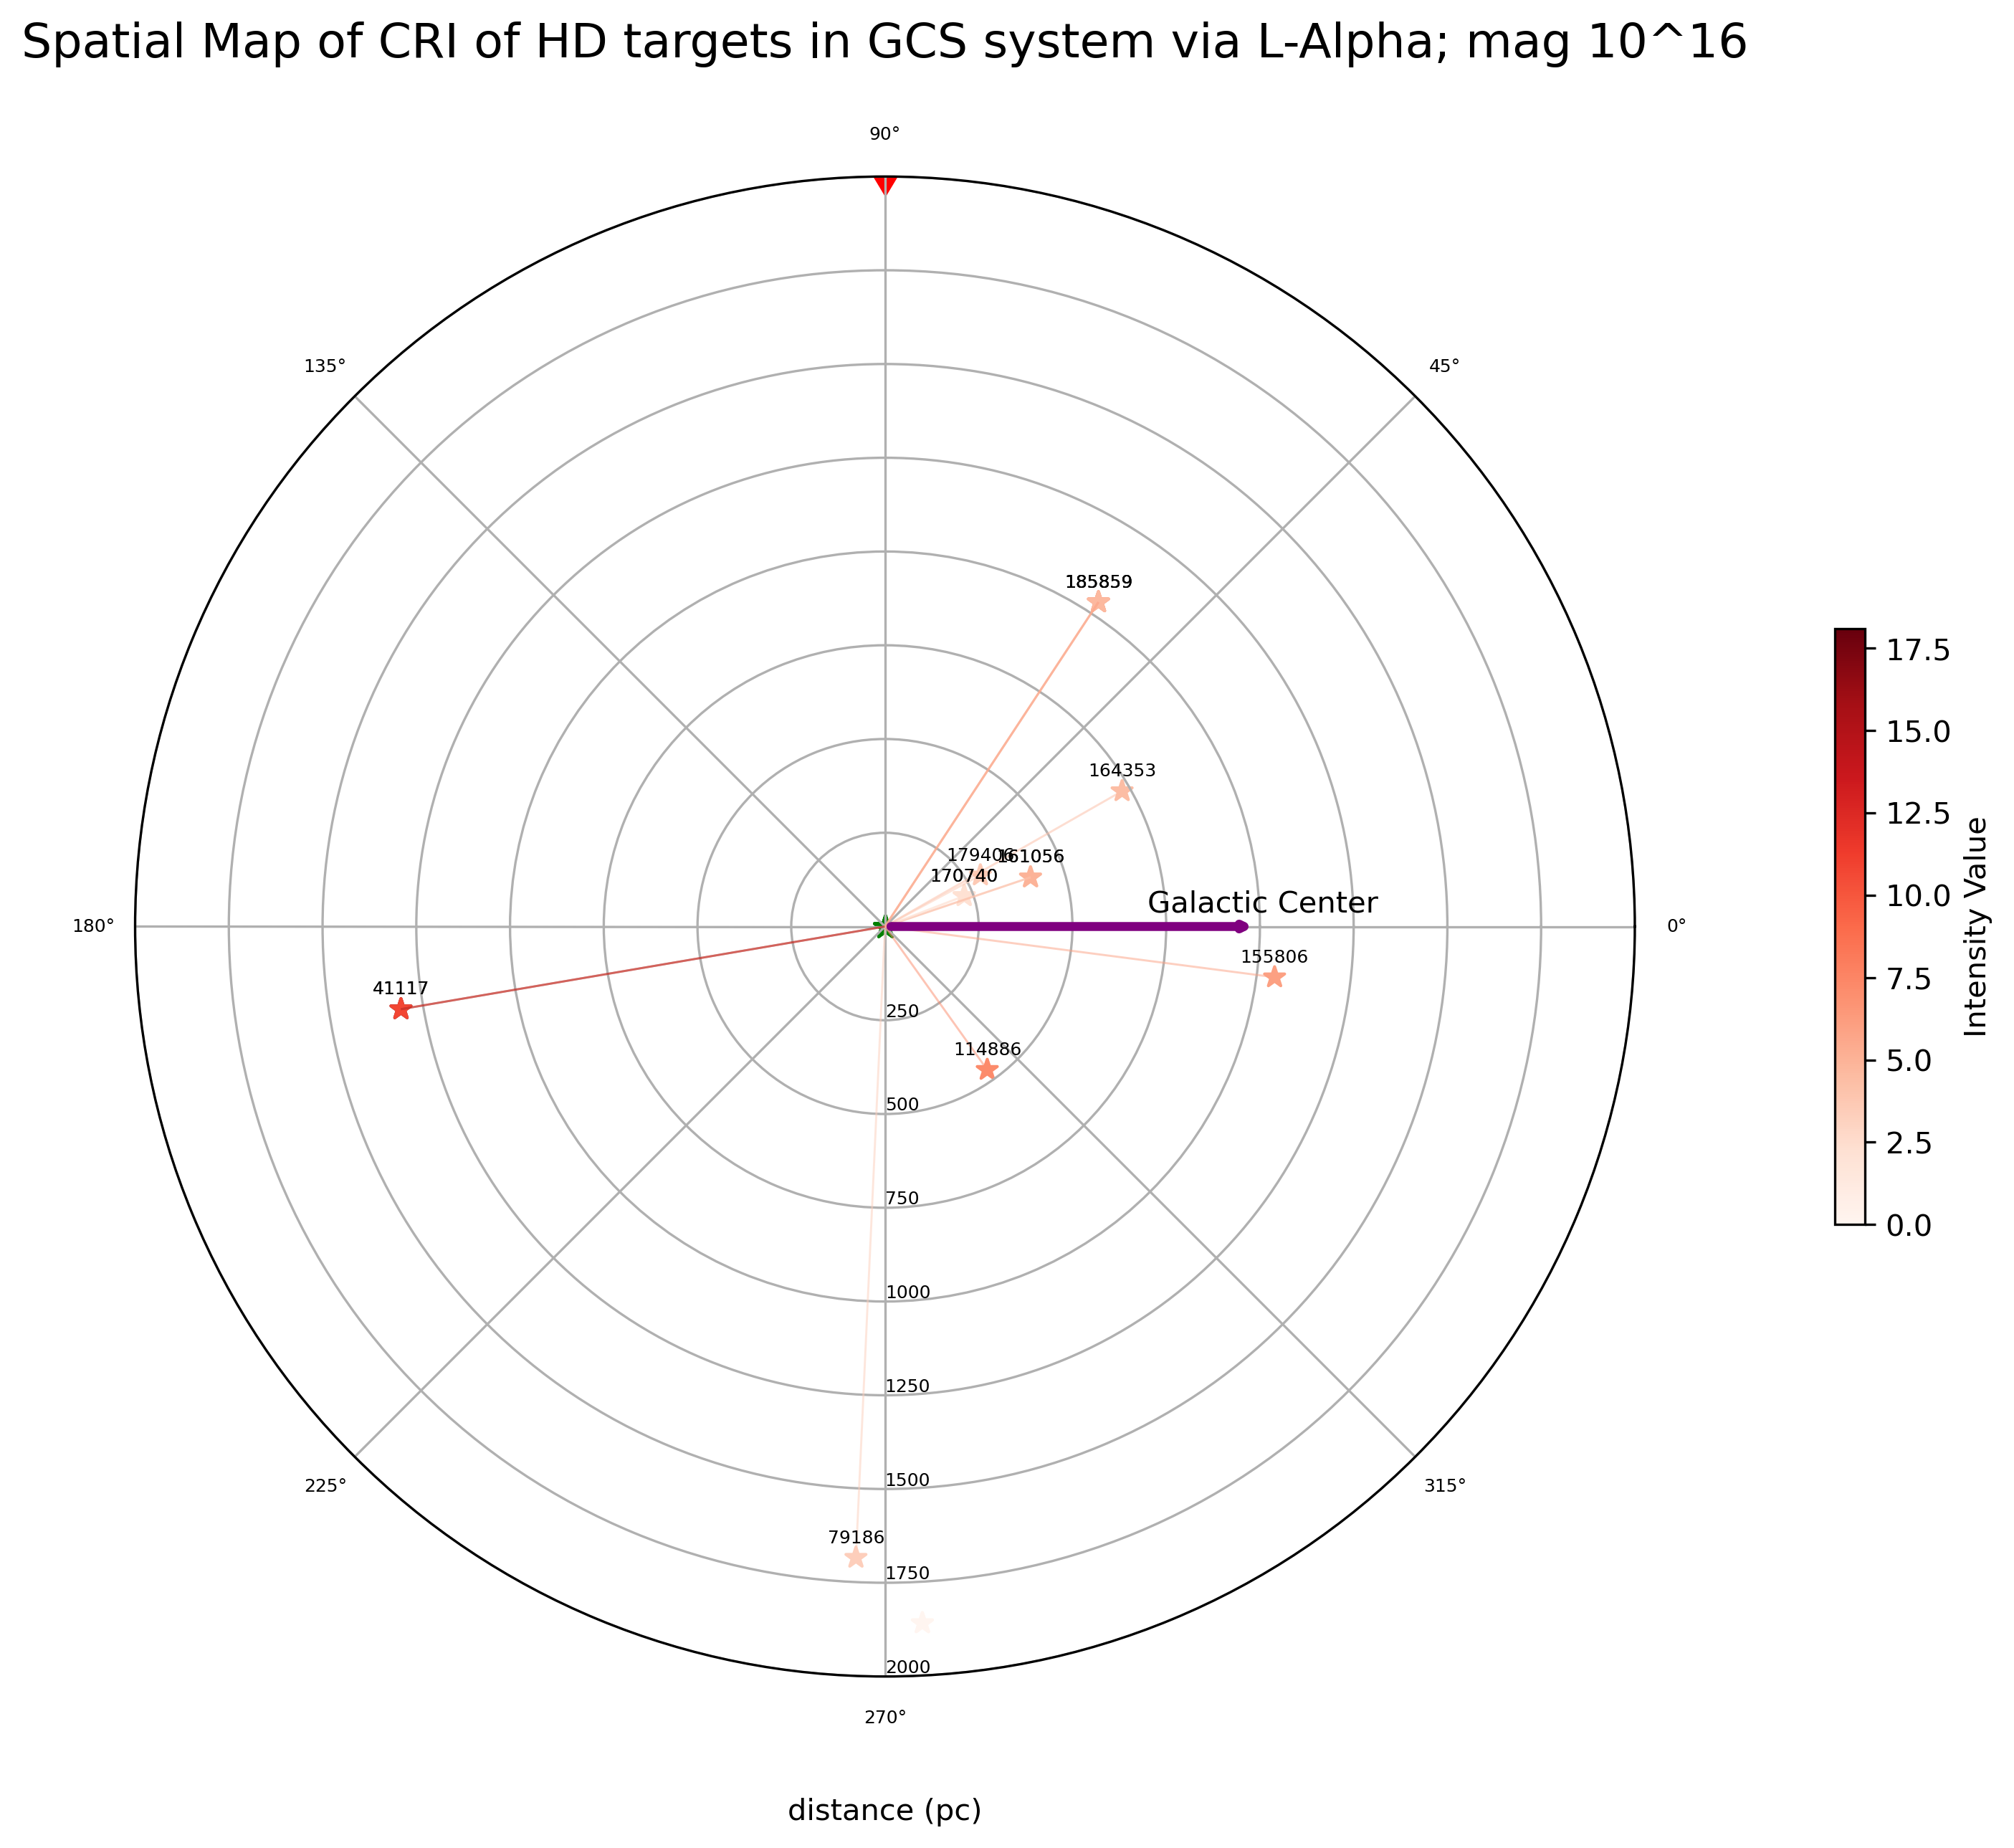

In [3]:
import matplotlib.cm as cm
from matplotlib.colors import Normalize

magnitude = np.nan_to_num(CRILAlpha, nan=0)
min_val = np.min(magnitude)
max_val = np.max(magnitude)

fig, ax = plt.subplots(figsize=(size, size), subplot_kw=dict(projection="polar"), dpi=dpi)
ax.set_title("Spatial Map of CRI of HD targets in GCS system via L-Alpha; mag 10^16", pad=40, fontsize=titlesize)
ax.tick_params(axis='both', labelsize=ticksize)
ax.grid(True)

ax.scatter(cs.l.radian, distances, s=30, marker='*', c='orange')
ax.annotate("Galactic Center", (cs.l.radian, 700), fontsize=10, textcoords='offset points', xytext=(0, 5))
ax.annotate("", xy=(0, 1000), fontsize=4, xytext=(0, 0),
            arrowprops=dict(facecolor="purple",edgecolor="purple",arrowstyle='->',lw=3))
ax.scatter(cp.l.radian, 2000, marker='d', c='red', s=70)
ax.set_ylabel("distance (pc)", va="bottom", rotation=0, ha='center')
ax.set_rlabel_position(270)
ax.yaxis.set_label_coords(0.5, -0.1)

# Multiplied by 1e16 to match your scatter data scaling
scaled_magnitude = magnitude * 1e16
a = ax.scatter(c.l.radian, distance, s=msize, c=scaled_magnitude, cmap=cmap, marker=marker)

ax.scatter(c2.l.radian, distance2, s=60, c='green', marker=marker)

# 1. Set up colormap tools using the same min/max scale as your scatter plot
cmap_obj = cm.get_cmap(cmap) if isinstance(cmap, str) else cmap
norm = Normalize(vmin=np.min(scaled_magnitude), vmax=np.max(scaled_magnitude))

for r in range(len(id)):
    if magnitude[r] == 0:
        continue
    
    # 2. Extract the specific color for the current line using its magnitude value
    current_color = cmap_obj(norm(scaled_magnitude[r]))
    
    # 3. Passed the mapped color into the vlines function
    ax.vlines(c.l.radian[r], 0, distance[r], linewidth=linewidth, linestyle='-', color=current_color, alpha=0.5)
    ax.annotate(f"{id[r][2:]}", (c.l[r].radian, distance[r]), fontsize=labelsize, textcoords='offset points', xytext=(0, 5), ha='center')

plt.colorbar(a, label='Intensity Value', orientation='vertical', pad=0.1, shrink=0.3)
ax.set_rmax(2000) 

fig.savefig("galacticmap L=alpha.png", format='png', dpi='figure')

C:\Users\Wasabi\AppData\Local\Temp\ipykernel_31696\360607362.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = cm.get_cmap(cmap) if isinstance(cmap, str) else cmap


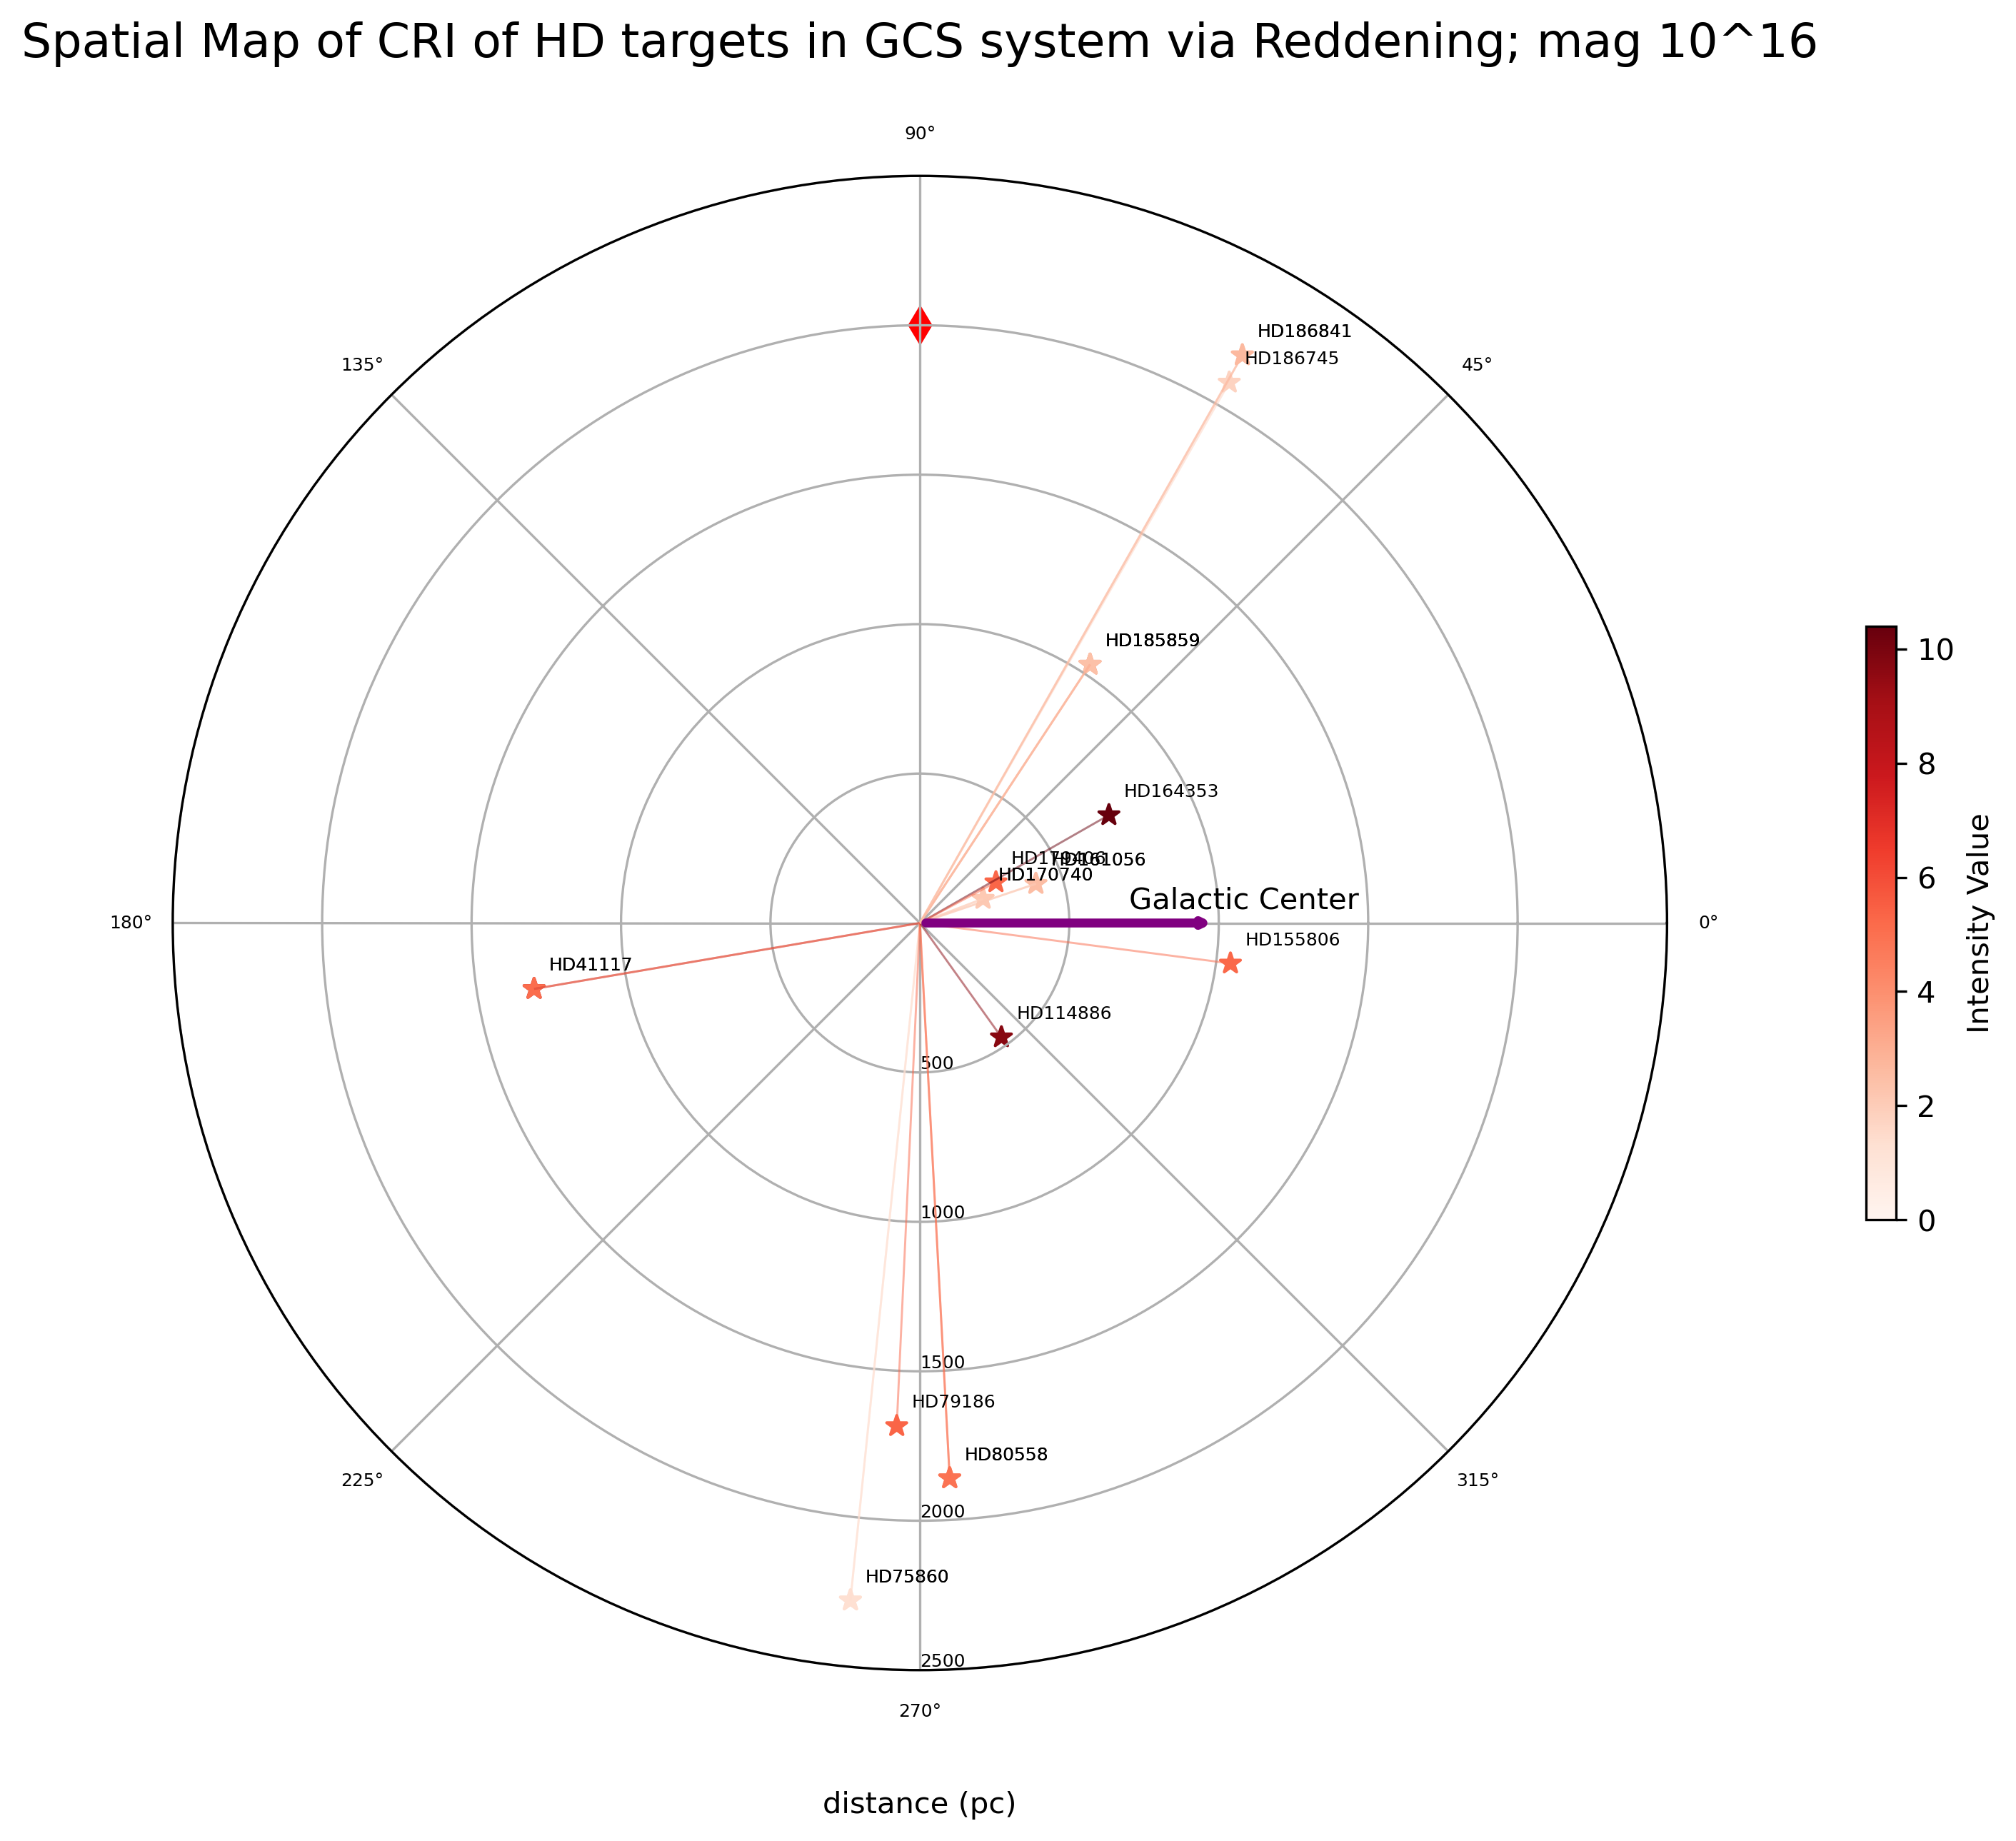

In [4]:
import matplotlib.cm as cm
from matplotlib.colors import Normalize

magnitude = np.nan_to_num(CRIR, nan=0)
min_val = np.min(magnitude)
max_val = np.max(magnitude)

fig, ax = plt.subplots(figsize=(size, size), subplot_kw=dict(projection="polar"), dpi=dpi)
ax.set_title("Spatial Map of CRI of HD targets in GCS system via Reddening; mag 10^16", pad=40, fontsize=titlesize)
ax.tick_params(axis='both', labelsize=ticksize)
ax.grid(True)

ax.scatter(cs.l.radian, distances, s=30, marker='*', c='orange')
ax.annotate("Galactic Center", (cs.l.radian, 700), fontsize=10, textcoords='offset points', xytext=(0, 5))
ax.annotate("", xy=(0, 1000), fontsize=4, xytext=(0, 0),
            arrowprops=dict(facecolor="purple",edgecolor="purple",arrowstyle='->',lw=3))
ax.scatter(cp.l.radian, 2000, marker='d', c='red', s=70)
ax.set_ylabel("distance (pc)", va="bottom", rotation=0, ha='center')
ax.set_rlabel_position(270)
ax.yaxis.set_label_coords(0.5, -0.1)

# Multiplied by 1e16 to match your scatter data scaling
scaled_magnitude = magnitude * 1e16
a = ax.scatter(c.l.radian, distance, s=msize, c=scaled_magnitude, cmap=cmap, marker=marker)

# 1. Set up colormap tools matching the scatter plot limits
cmap_obj = cm.get_cmap(cmap) if isinstance(cmap, str) else cmap
norm = Normalize(vmin=np.min(scaled_magnitude), vmax=np.max(scaled_magnitude))

for r in range(len(id)):
    if magnitude[r] == 0:
        continue
        
    # 2. Extract the specific color for the current line
    current_color = cmap_obj(norm(scaled_magnitude[r]))
    
    # 3. Passed the mapped color into the vlines function
    ax.vlines(c.l.radian[r], 0, distance[r], linewidth=linewidth, linestyle='-', color=current_color, alpha=0.5)
    
    # Text annotation with your preferred padding settings
    ax.annotate(f"{id[r]}", 
                (c.l[r].radian, distance[r]), 
                fontsize=labelsize, 
                textcoords='offset points', 
                xytext=(5, 5),   
                ha='left',      
                va='bottom')    

plt.colorbar(a, label='Intensity Value', orientation='vertical', pad=0.1, shrink=0.3)
ax.set_rmax(2500.0) 

fig.savefig("galacticmap Red.png", format='png', dpi='figure')

C:\Users\Wasabi\AppData\Local\Temp\ipykernel_31696\3178781416.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = cm.get_cmap(cmap) if isinstance(cmap, str) else cmap


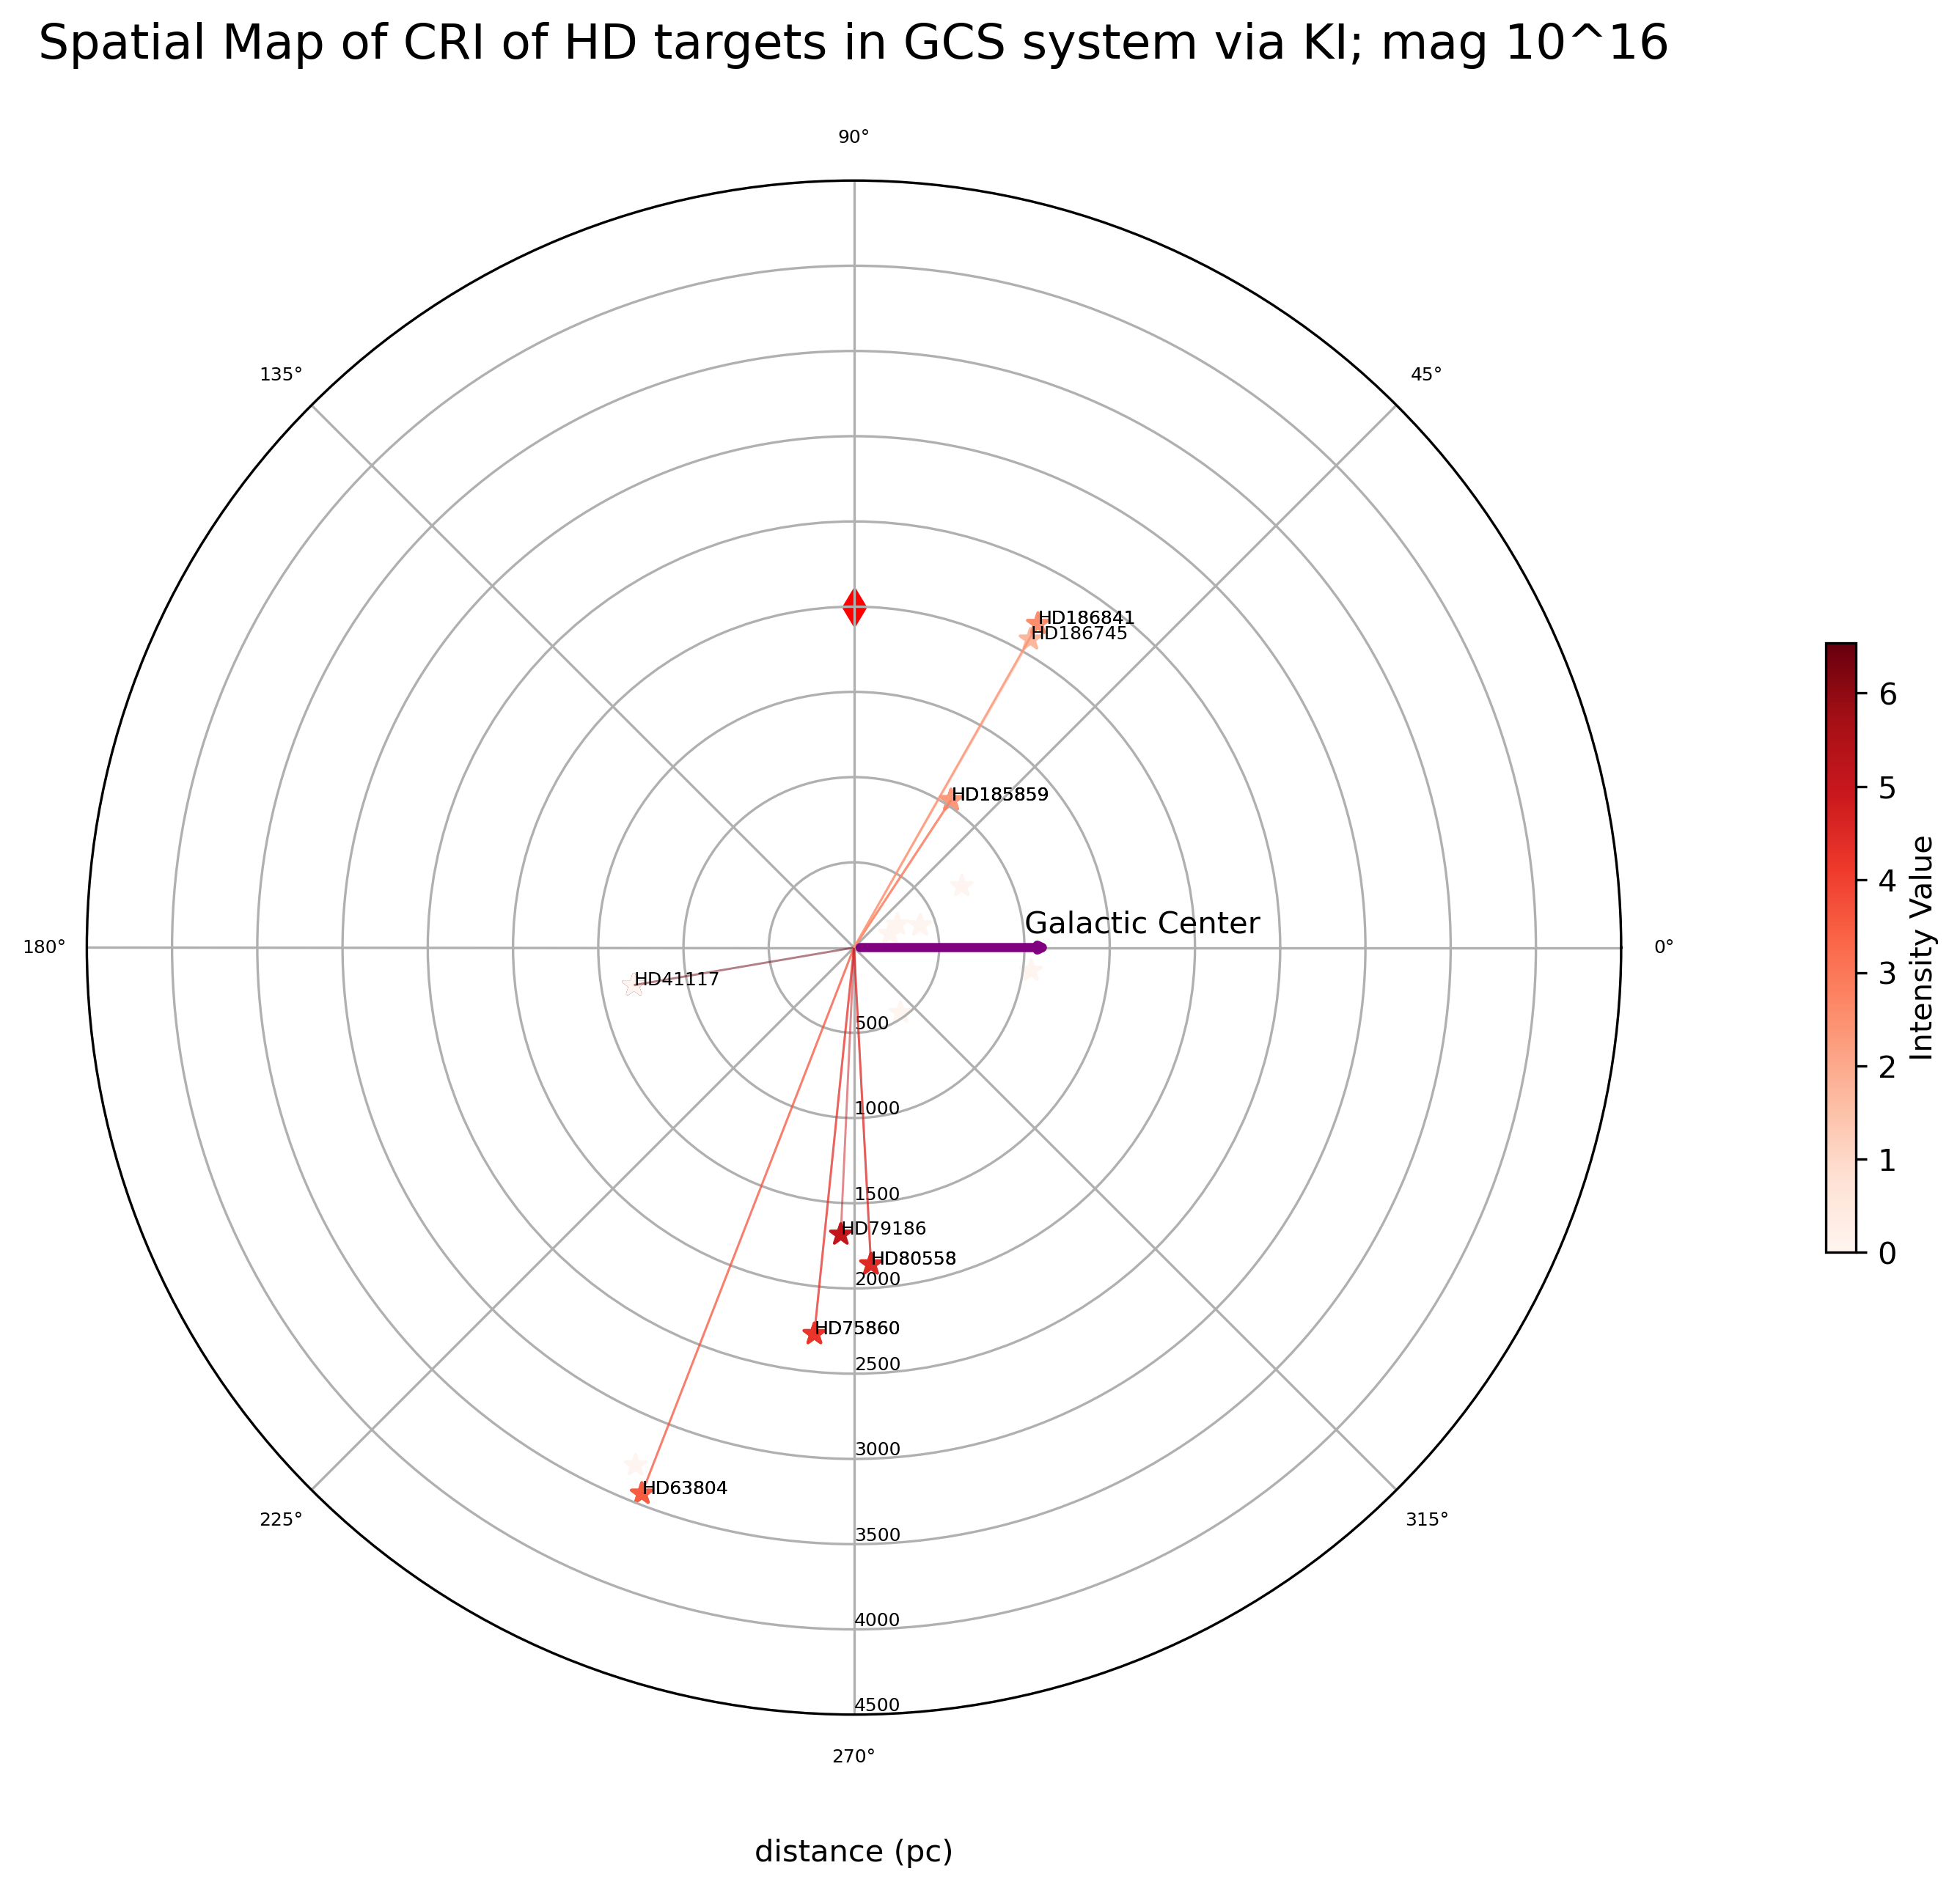

In [5]:
import matplotlib.cm as cm
from matplotlib.colors import Normalize

magnitude = np.nan_to_num(CRIK, nan=0)
min_val = np.min(magnitude)
max_val = np.max(magnitude)

fig, ax = plt.subplots(figsize=(size, size), subplot_kw=dict(projection="polar"), dpi=dpi)
ax.set_title("Spatial Map of CRI of HD targets in GCS system via KI; mag 10^16", pad=40, fontsize=titlesize)
ax.tick_params(axis='both', labelsize=ticksize)
ax.grid(True)

ax.scatter(cs.l.radian, distances, s=30, marker='*', c='orange')
ax.annotate("Galactic Center", (cs.l.radian, 1000), fontsize=10, textcoords='offset points', xytext=(0, 5))
ax.annotate("", xy=(0, 1200), fontsize=4, xytext=(0, 0),
            arrowprops=dict(facecolor="purple",edgecolor="purple",arrowstyle='->',lw=3))
ax.scatter(cp.l.radian, 2000, marker='d', c='red', s=70)
ax.set_ylabel("distance (pc)", va="bottom", rotation=0, ha='center')
ax.set_rlabel_position(270)
ax.yaxis.set_label_coords(0.5, -0.1)

# Multiplied by 1e16 to match your scatter data scaling
scaled_magnitude = magnitude * 1e16
a = ax.scatter(c.l.radian, distance, s=msize, c=scaled_magnitude, cmap=cmap, marker=marker)

# 1. Set up colormap tools using the same min/max scale as your scatter plot
cmap_obj = cm.get_cmap(cmap) if isinstance(cmap, str) else cmap
norm = Normalize(vmin=np.min(scaled_magnitude), vmax=np.max(scaled_magnitude))

for r in range(len(id)):
    if magnitude[r] == 0:
        continue
    
    # 2. Extract the specific color for the current line using its magnitude value
    current_color = cmap_obj(norm(scaled_magnitude[r]))
    
    # 3. Passed the mapped color into the vlines function
    ax.vlines(c.l.radian[r], 0, distance[r], linewidth=linewidth, linestyle='-', color=current_color, alpha=0.5)
    ax.annotate(f"{id[r]}", (c.l[r].radian, distance[r]), fontsize=labelsize, textcoords='offset points', xytext=(0, 0))
    
ax.set_rmax(4500.0) 

plt.colorbar(a, label='Intensity Value', orientation='vertical', pad=0.1, shrink=0.3)

fig.savefig("galacticmap K.png", format='png', dpi='figure')